## Research Question

1. Is the proportion of students who feel sad or hopeless different from 0.30?

2. Is the mean BMIPCT different from 65?

## Variable Definition

SadOrHopeless:
1 = Yes (success)
2 = No (failure)

BMIPCT:
Continuous variable representing BMI percentile.

In [5]:
import csv

file_path = "../data/raw/YRBS_2007.csv"

data = []
with open(file_path, newline='', encoding='utf-8') as f:
    reader = csv.DictReader(f)
    for row in reader:
        data.append(row)

print("Total rows:", len(data))

Total rows: 14041


In [6]:
missing_sad = 0
missing_bmi = 0

for row in data:
    if row["SadOrHopeless"] == "":
        missing_sad += 1
    if row["BMIPCT"] == "":
        missing_bmi += 1

print("Missing SadOrHopeless:", missing_sad)
print("Missing BMIPCT:", missing_bmi)

Missing SadOrHopeless: 196
Missing BMIPCT: 979


## Approved Variables and Benchmarks

### Proportion Variable
Variable: SadOrHopeless

Definition:
This variable indicates whether a student felt sad or hopeless.

Coding:
1 = Yes (success)
2 = No (failure)

Recoding rule:
1 → 1 (success)
2 → 0 (failure)

Benchmark:
p0 = 0.30

---

### Mean Variable
Variable: BMIPCT

Definition:
This variable represents BMI percentile.

Benchmark:
μ0 = 65

## Sad or Hopeless

In [7]:
values = []

for row in data:
    val = row["SadOrHopeless"]
    if val != "":
        values.append(int(val))

freq = {}
for v in values:
    freq[v] = freq.get(v, 0) + 1

print("Original frequency:", freq)

Original frequency: {1: 4153, 2: 9692}


### Recoding

In [8]:
binary = []

for v in values:
    if v == 1:
        binary.append(1)
    elif v == 2:
        binary.append(0)

print("Success (1):", binary.count(1))
print("Failure (0):", binary.count(0))

Success (1): 4153
Failure (0): 9692


### Proportion

In [9]:
n = len(binary)
p_hat = sum(binary) / n

print("Sample size:", n)
print("p̂ =", round(p_hat, 3))
print("Percentage:", round(p_hat * 100, 1), "%")

Sample size: 13845
p̂ = 0.3
Percentage: 30.0 %


### Graph

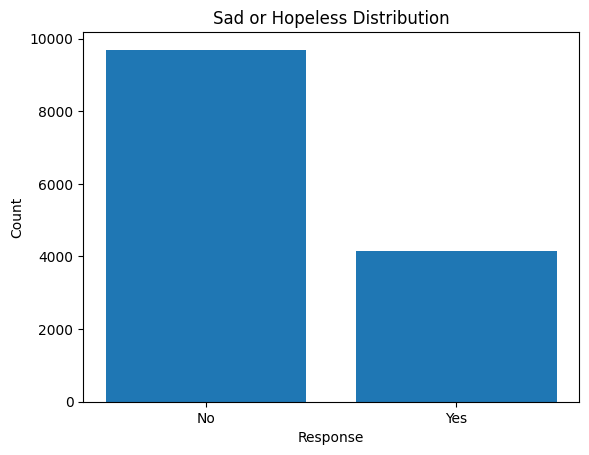

In [10]:
import matplotlib.pyplot as plt

plt.bar(["No", "Yes"], [binary.count(0), binary.count(1)])
plt.xlabel("Response")
plt.ylabel("Count")
plt.title("Sad or Hopeless Distribution")
plt.show()

### Interpretation (SadOrHopeless)

The proportion of students who feel sad or hopeless is approximately p̂ = 0.3.

This suggests that a considerable number of students experience negative emotions.

## BMIPCT

In [11]:
bmi = []

for row in data:
    val = row["BMIPCT"]
    if val != "":
        bmi.append(float(val))

### statistics

In [12]:
import math

n = len(bmi)
mean = sum(bmi) / n

variance = sum((x - mean)**2 for x in bmi) / (n - 1)
std = math.sqrt(variance)

bmi_sorted = sorted(bmi)

median = bmi_sorted[n//2]

Q1 = bmi_sorted[n//4]
Q3 = bmi_sorted[3*n//4]

print("n =", n)
print("mean =", round(mean, 2))
print("median =", round(median, 2))
print("std =", round(std, 2))
print("min =", min(bmi))
print("max =", max(bmi))
print("Q1 =", Q1)
print("Q3 =", Q3)

n = 13062
mean = 64.82
median = 70.15
std = 27.52
min = 3.72e-09
max = 99.93921341
Q1 = 45.16626978
Q3 = 89.45507565


### Graph

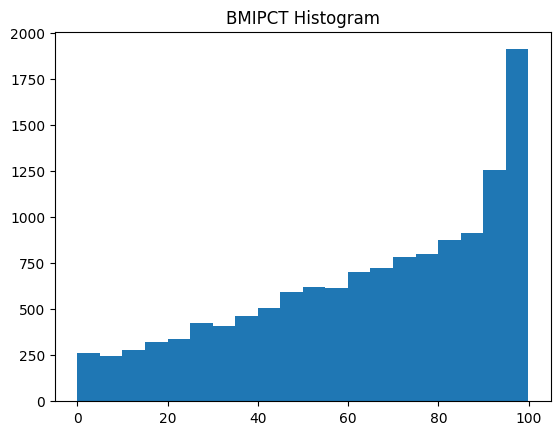

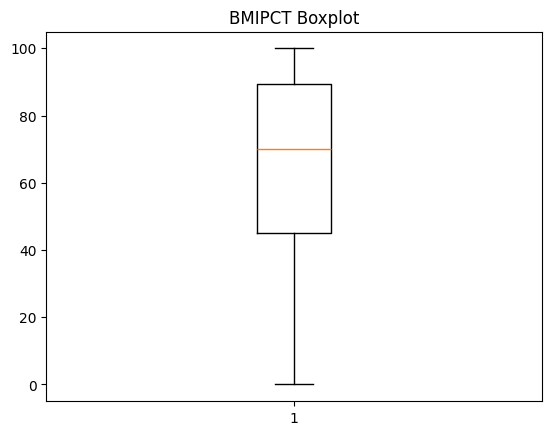

In [13]:
plt.hist(bmi, bins=20)
plt.title("BMIPCT Histogram")
plt.show()

plt.boxplot(bmi)
plt.title("BMIPCT Boxplot")
plt.show()

### Interpretation (BMIPCT)

The mean BMIPCT is 64.82 with a standard deviation of 27.52.

The histogram shows that the distribution is slightly skewed.

Some potential outliers are observed in the boxplot.